# Tumor CD8+ T Cell dynamic GRNs Analysis
This notebook integrates all analysis pipelines in the `tumor_CD8T_jupyter` directory.

**Execution Flow**:
1. **Dynamic GRN Rewiring**: Train model and reconstruct dynamic GRNs.
2. **Quantification of Network Entropy Dynamics**: Calculate the network entropy change of dynamic GRNs during the exhaustion process of CD8+ T cells.
3. **Entropy-Based Identification of Key Genes**: Identifying key genes using scDGRN in combination with dynamic GRNs.
4. **Differentially Expressed Gene (DEG) Analysis**: Calculate the differentially expressed genes and compare them with scDGRN.
5. **Dynamics of Gene Expression and Regulatory Activity**: Analyze the expression patterns and regulatory activity changes of the genes with low expression and high activity characteristics discovered.
6. **Exhaustion Dynamics and KEGG Enrichment of the ETV7 Subnetwork**: Focus on the terminal exhaustion network dynamics and functional transformation of ETV7.
7. **In Silico Gene Perturbation Analysis**: Utilizing CellOracle to conduct in silico perturbation on the dynamic GRNs that we have inferred.
**Environment**: Current kernel is `pytorch`. In silico perturbation is executed via `conda run` in `celloracle_env`.

## 1. Data preparation
* **TF.csv**：the focused transcription factors.
* **Target.csv**：target gene list, generally, the top highly variable genes are selected for analysis.
* **Train_set_TL.csv**：the collected prior regulations that can be used for pre-training. The gene names need to be mapped to the corresponding index numbers of the target gene list.
* **fine_tune.csv**：The collected prior regulations that can be used for fine-tuning.
* **tumor_expression0/1/2/3.csv**：time-series single-cell expression data. This dataset is divided into four fine-grained stages based on the literature of the dataset or through pseudo-time-series clustering.
  
**The specific forms of all the data can be found in the sample data we have provided.**

## 2. Model training

In [2]:
# import sys
# import os
# print(sys.executable)
# print("current working directory:", os.getcwd())
%run Train_dgrn_main_tumor.py

  (7, 134)	1.0
  (134, 7)	1.0
  (7, 1756)	1.0
  (1756, 7)	1.0
  (7, 2403)	1.0
  (2403, 7)	1.0
  (7, 3305)	1.0
  (3305, 7)	1.0
  (7, 1999)	1.0
  (1999, 7)	1.0
  (7, 58)	1.0
  (58, 7)	1.0
  (7, 2478)	1.0
  (2478, 7)	1.0
  (7, 957)	1.0
  (957, 7)	1.0
  (7, 911)	1.0
  (911, 7)	1.0
  (7, 2945)	1.0
  (2945, 7)	1.0
  (7, 2253)	1.0
  (2253, 7)	1.0
  (7, 486)	1.0
  (486, 7)	1.0
  (7, 4396)	1.0
  :	:
  (318, 4262)	1.0
  (4262, 3477)	1.0
  (3477, 4262)	1.0
  (4262, 1840)	1.0
  (1840, 4262)	1.0
  (4262, 4374)	1.0
  (4374, 4262)	1.0
  (4262, 2106)	1.0
  (2106, 4262)	1.0
  (4262, 2948)	1.0
  (2948, 4262)	1.0
  (4262, 2186)	1.0
  (2186, 4262)	1.0
  (4262, 2251)	1.0
  (2251, 4262)	1.0
  (4262, 720)	1.0
  (720, 4262)	1.0
  (4262, 1157)	1.0
  (1157, 4262)	1.0
  (4262, 627)	1.0
  (627, 4262)	1.0
  (4262, 4078)	1.0
  (4078, 4262)	1.0
  (4262, 935)	1.0
  (935, 4262)	1.0
tensor(indices=tensor([[   7,  134,    7,  ..., 4078, 4262,  935],
                       [ 134,    7, 1756,  ..., 4262,  935, 4262]]),
  

/home/llliu/dynGRN/scDGRN/Transfer_learning/tumor_CD8T_jupyter/Train_dgrn_main_tumor.py:397: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(m

Epoch:1 train loss:17.334607779979706
Epoch:2 train loss:16.423101902008057
Epoch:3 train loss:16.003247618675232
Epoch:4 train loss:15.770274937152863
Epoch:5 train loss:15.699873685836792
Epoch:6 train loss:15.59892725944519
Epoch:7 train loss:15.466103613376617
Epoch:8 train loss:15.556692957878113
Epoch:9 train loss:15.48186480998993
Epoch:10 train loss:15.41816520690918
Epoch:11 train loss:15.46515166759491
Epoch:12 train loss:15.455782353878021
Epoch:13 train loss:15.464282751083374
Epoch:14 train loss:15.38983690738678
Epoch:15 train loss:15.397330343723297
Model fine-tuning is complete!


## 3. Dynamic GRNs rewiring

In [1]:
%run Reconstruct_output_tumor_GRNs.py

     TF  Target     score
0  1999      71  0.425039
1  1999      72  0.395760
2  1999      73  0.437492
3  1999      74  0.431416
4  1999      75  0.423429
The GRN at time t1 is:
           TF  Target     score
189769   HIC1   AP4M1  0.642692
224529   RFX3   AP4M1  0.637908
61791   GATA3    LMF2  0.628292
176734   ETV7   AP4M1  0.622270
228874  SMAD7   AP4M1  0.621184
...       ...     ...       ...
223261   RFX3    NMT2  0.372520
222006   RFX3   PTPN7  0.372233
190068   HIC1  TRAV25  0.371684
225255   RFX3  CRYBG2  0.371683
224828   RFX3  TRAV25  0.360242

[308495 rows x 3 columns]
The reconstructed dynamic GRNs have been saved to: ./cytoscape/tumor_prediction1/2/3/4_3000.csv
The GRN at time t2 is:
            TF   Target     score
188535    HIC1    NEPRO  0.620658
249365   NR4A2    NEPRO  0.618206
227640   SMAD7    NEPRO  0.608932
112181  NFE2L2  A2M-AS1  0.608067
223295    RFX3    NEPRO  0.598378
...        ...      ...       ...
216383    RBPJ    PCAT1  0.171909
298938    ELF1    P

## 4. Network entropy change

0.0729325323634437
0.4089335209563985
0.5127899463104262
0.6024330804204777


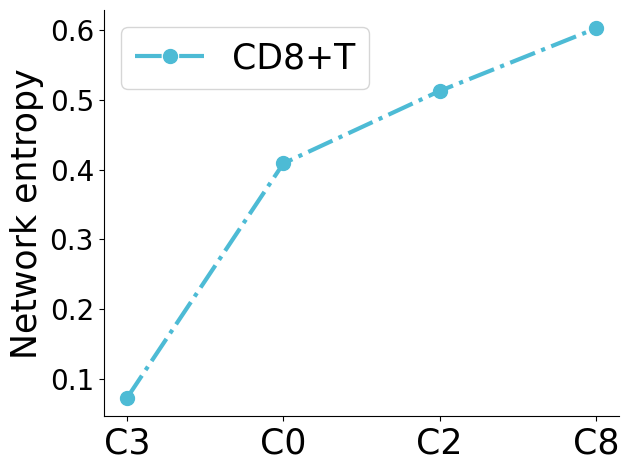

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
import math
import pandas as pd

def calculate_entropy(network):
    all_nodes = [node for edge in network for node in edge]
    node_degrees = dict(Counter(all_nodes))
    total_nodes = len(node_degrees)
    degree_counts = dict(Counter(node_degrees.values()))
    entropy = 0
    for degree in degree_counts.values():
        #degree_count = list(node_degrees.values()).count(degree)
        probability = degree / total_nodes
        entropy -= probability * math.log2(probability)
    entropy = entropy / math.log2(total_nodes)  # 
    return entropy


network_list = []
for i in range(1,5):

    df = pd.read_csv("./cytoscape/tumor_prediction" + str(i) + "_3000.csv")
    result = [(row[0], row[1]) for row in df.values]
    network_list.append(result)

entropy_total2 = []
for network in network_list:
    entropy = calculate_entropy(network)
    print(entropy)
    entropy_total2.append(entropy)

plt.plot(range(len(entropy_total2)),entropy_total2,marker='o',markersize=10,label='CD8+T',color = '#4dbbd5',linestyle = '-.',linewidth=3)

plt.ylabel('Network entropy',fontsize=25)
plt.xticks([0,1,2,3],['C3','C0','C2','C8'],fontsize=25)
plt.yticks(fontsize=20)

plt.legend(fontsize=25)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Key regulator identification

Top 20 genes:
0         AHR
1        ETV7
2        PURA
3        ETS1
4       ZFP36
5       TBX21
6       MECP2
7        BRD2
8        HIC1
9      ZBTB7B
10      NR4A2
11       NME2
12       RFX3
13      REEP5
14      PCBP1
15       ELF2
16       ZEB1
17       ELF1
18      SMAD7
19    ZFP36L2
Name: gene, dtype: object

List of top 20 genes:
['AHR', 'ETV7', 'PURA', 'ETS1', 'ZFP36', 'TBX21', 'MECP2', 'BRD2', 'HIC1', 'ZBTB7B', 'NR4A2', 'NME2', 'RFX3', 'REEP5', 'PCBP1', 'ELF2', 'ZEB1', 'ELF1', 'SMAD7', 'ZFP36L2']

Perturbation scores (log-scaled):
0     9.307830
1     5.564966
2     3.975088
3     3.323563
4     3.041266
5     3.029542
6     2.854801
7     2.787618
8     2.599045
9     2.494152
10    2.475600
11    2.452293
12    2.240914
13    2.227103
14    2.074075
15    1.992599
16    1.962971
17    1.957694
18    1.951327
19    1.938799
Name: R_score, dtype: float64


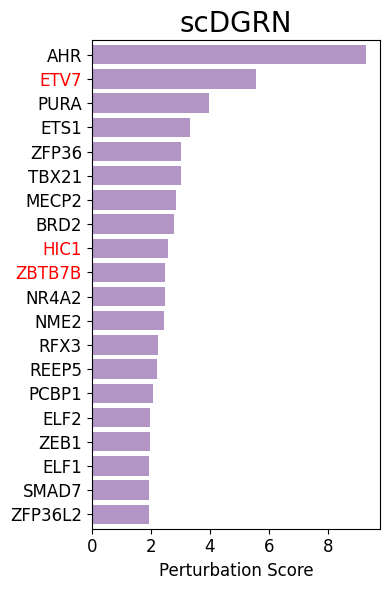

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import numpy as np

df_tf = pd.read_csv("TF.csv")
df_target = pd.read_csv("Target.csv")
dic_index_gene = df_target.set_index("index")["Gene"].to_dict()

sorted_df = pd.read_csv("./key_gene_entropy_top3000_normalize.csv")

gene_list = []
for i in list(sorted_df["gene"].values):
    gene_list.append(i)
sorted_df["gene"] = gene_list

top_20_genes = sorted_df['gene'].head(20)
top_20_genes = top_20_genes.str.upper()
top_20_genes.to_csv("./top20_gene_pertur.csv", index=False)

top_20_scores = sorted_df['R_score'].head(20)
top_20_scores = np.log(top_20_scores * 1000000)

fig, ax = plt.subplots()
bars = ax.barh(top_20_genes, top_20_scores, color='#b295c5')

print("Top 20 genes:")
print(top_20_genes)
print("\nList of top 20 genes:")
print(list(top_20_genes))
print("\nPerturbation scores (log-scaled):")
print(top_20_scores)

ax.invert_yaxis()
ax.set_xlabel('Perturbation Score', fontsize=12)
ax.margins(y=0.01)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.set_title('scDGRN', fontsize=20)

fig.set_size_inches(4, 6)
plt.tight_layout()

target_genes = ['ETV7', 'HIC1', 'ZBTB7B']
for ticklabel in ax.get_yticklabels():
    if ticklabel.get_text() in target_genes:
        ticklabel.set_color('red')

plt.show()

## 6. Ranking of differentially expressed genes

/home/llliu/anaconda3/envs/pytorch/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Subset of selected genes with ranking and score:
         p_value  adj_p_value  log2_fold_change     score  ranking
ETV7    0.020045     0.058352          4.106476  1.697990     1517
HIC1    0.805053     0.879952               inf  0.094175     4041
ZBTB7B  0.017756     0.052732          2.022637  1.750644     1487


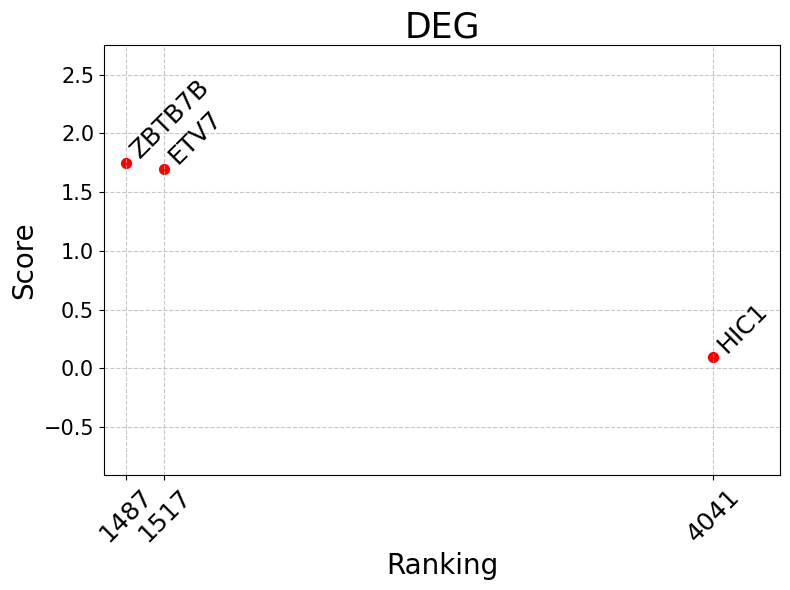

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests


df1 = pd.read_csv('./tumor_expression0.csv', index_col=0)
df2 = pd.read_csv('./tumor_expression1.csv', index_col=0)
df3 = pd.read_csv('./tumor_expression2.csv', index_col=0)
df4 = pd.read_csv('./tumor_expression3.csv', index_col=0)

p_values = []
for gene in df1.index:
    group1_data = df1.loc[gene].dropna()
    group2_data = df2.loc[gene].dropna()
    group3_data = df3.loc[gene].dropna()
    group4_data = df4.loc[gene].dropna()

    try:
        f_stat, p = stats.f_oneway(group1_data, group2_data, group3_data, group4_data)
        p_values.append(p)
    except ValueError:
        p_values.append(np.nan)
        print("Skipped gene due to empty group data")

result_df = pd.DataFrame(index=df1.index)
result_df['p_value'] = p_values

_, adj_p_values, _, _ = multipletests(result_df['p_value'], method='fdr_bh')
result_df['adj_p_value'] = adj_p_values

mean1 = df1.mean(axis=1)
mean2 = df2.mean(axis=1)
mean3 = df3.mean(axis=1)
mean4 = df4.mean(axis=1)

mean_df = pd.concat([mean1, mean2, mean3, mean4], axis=1)
mean_df.columns = ['group1', 'group2', 'group3', 'group4']

mean_df['fold_change'] = mean_df.max(axis=1) / mean_df.min(axis=1)
mean_df['log2_fold_change'] = np.log2(mean_df['fold_change'])

result_df = pd.concat([result_df, mean_df[['log2_fold_change']]], axis=1)

diff_genes = result_df[(result_df['adj_p_value'] < 1) & (np.abs(result_df['log2_fold_change']) > 0)]
ranked_genes = diff_genes.sort_values(by='adj_p_value')

# print("Differentially Expressed Genes Ranking:")
# print(ranked_genes[['adj_p_value', 'log2_fold_change']].head(20))
# print("List of ranked gene names:")
# print(ranked_genes.index.tolist())
# print("Full ranked genes data:")
# print(ranked_genes)

df = ranked_genes
df['score'] = -np.log10(df['p_value'])

selected_genes = ['ETV7', 'HIC1', 'ZBTB7B']
subset_df = df.loc[selected_genes].copy()

subset_df['ranking'] = [df.index.tolist().index(gene) + 1 for gene in subset_df.index]
print("Subset of selected genes with ranking and score:")
print(subset_df)

def custom_transform(rankings):
    min_rank = min(rankings)
    max_rank = max(rankings)
    transformed = []
    for rank in rankings:
        if rank in [1487, 1517]:
            if rank == 1487:
                transformed.append(rank - 70)
            else:
                transformed.append(rank + 70)
        else:
            transformed.append(rank)
    return np.array(transformed)

transformed_rankings = custom_transform(subset_df['ranking'])

plt.figure(figsize=(8, 6))
plt.scatter(transformed_rankings, subset_df['score'], color='red', s=50)

for i, row in subset_df.iterrows():
    index = subset_df.index.tolist().index(i)
    plt.text(
        transformed_rankings[index], row['score'], row.name,
        va='bottom', ha='left',
        rotation=45,
        fontsize=18
    )

plt.xticks(transformed_rankings, subset_df['ranking'], fontsize=18, rotation=45)
plt.yticks(fontsize=15)
plt.xlabel('Ranking', fontsize=20)
plt.ylabel('Score', fontsize=20)
plt.title('DEG', fontsize=25)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(min(transformed_rankings) - 100, max(transformed_rankings) + 300)
plt.ylim(min(subset_df['score']) - 1, max(subset_df['score']) + 1)

plt.tight_layout()
plt.show()

## 7. Dynamic expression and regulatory activity heatmaps

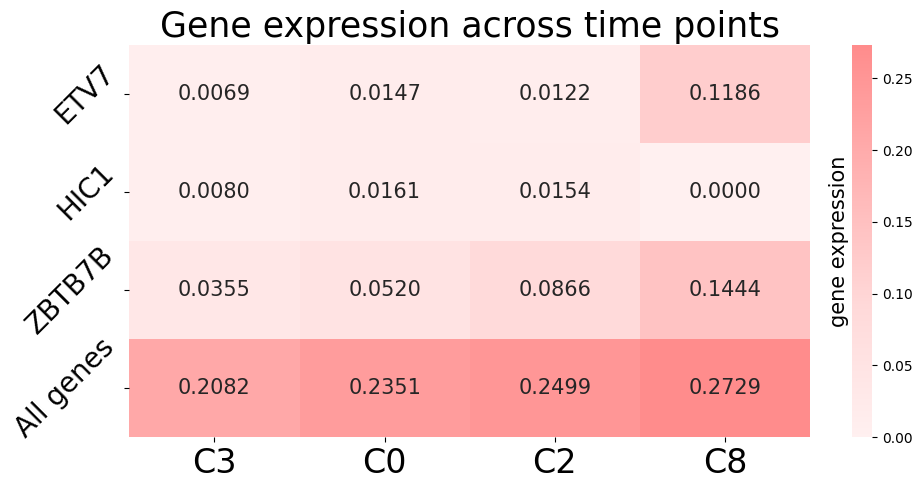

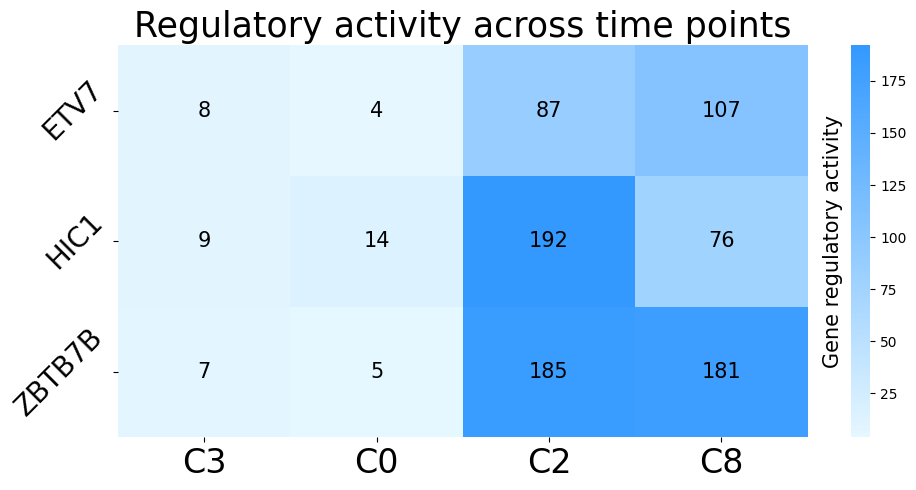

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------- Gene Expression Heatmap --------------------------
# Read expression data
df1 = pd.read_csv('tumor_expression0.csv', index_col=0)
df2 = pd.read_csv('tumor_expression1.csv', index_col=0)
df3 = pd.read_csv('tumor_expression2.csv', index_col=0)
df4 = pd.read_csv('tumor_expression3.csv', index_col=0)

# Define target genes
genes = ['ETV7', 'HIC1', 'ZBTB7B']

# Calculate mean expression for each gene across time points
heatmap_data = {}
for gene in genes:
    mean1 = df1.loc[gene].mean()
    mean2 = df2.loc[gene].mean()
    mean3 = df3.loc[gene].mean()
    mean4 = df4.loc[gene].mean()
    heatmap_data[gene] = [mean1, mean2, mean3, mean4]

# Calculate global mean expression for all genes
all_genes_mean_1 = df1.mean().mean()
all_genes_mean_2 = df2.mean().mean()
all_genes_mean_3 = df3.mean().mean()
all_genes_mean_4 = df4.mean().mean()
heatmap_data['All genes'] = [all_genes_mean_1, all_genes_mean_2, all_genes_mean_3, all_genes_mean_4]

# Convert to DataFrame
heatmap_df = pd.DataFrame.from_dict(heatmap_data, orient='index', columns=['C3', 'C0', 'C2', 'C8'])

# Custom colormap (light pink to dark pink)
colors = ['#FFF0F0', '#FFD9D9', '#FFB3B3', '#FF8C8C']
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Plot expression heatmap
plt.figure(figsize=(10, 5))
ax = sns.heatmap(
    heatmap_df,
    cmap=cmap,
    annot=True,
    fmt=".4f",
    cbar=True,
    xticklabels=True,
    yticklabels=True,
    annot_kws={"size": 15}
)

# Customize colorbar
cbar = ax.collections[0].colorbar
cbar.set_label('gene expression', rotation=90, labelpad=-60, fontsize=15)

# Set plot properties
plt.title('Gene expression across time points', fontsize=25)
plt.xticks(rotation=0, fontsize=24)
plt.yticks(fontsize=20, rotation=45)
plt.tight_layout()
plt.show()

# -------------------------- Gene Regulatory Activity Heatmap --------------------------
# Define regulatory activity data
regulation_data = {
    'ETV7': [8, 4, 87, 107],
    'HIC1': [9, 14, 192, 76],
    'ZBTB7B': [7, 5, 185, 181]
}

# Convert to DataFrame
heatmap_df = pd.DataFrame.from_dict(regulation_data, orient='index', columns=['C3', 'C0', 'C2', 'C8'])

# Custom colormap (light blue to dark blue)
colors = ['#E6F7FF', '#3399FF']
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Plot regulatory activity heatmap
plt.figure(figsize=(10, 5))
ax = sns.heatmap(
    heatmap_df,
    cmap=cmap,
    annot=True,
    fmt=".0f",
    cbar=True,
    xticklabels=True,
    yticklabels=True,
    annot_kws={"size": 15, "color":"black"}
)

# Customize colorbar
cbar = ax.collections[0].colorbar
cbar.set_label('Gene regulatory activity', rotation=90, labelpad=-60, fontsize=15)

# Set plot properties
plt.title('Regulatory activity across time points', fontsize=25)
plt.xticks(rotation=0, fontsize=24)
plt.yticks(fontsize=20, rotation=45)
plt.tight_layout()
plt.show()

## 8. Subnetwork and KEGG Enrichment

ETV7 subnetwork for time point 1:
        TF   Target     score  e_type
3     ETV7    AP4M1  0.622270       0
22    ETV7     E2F1  0.600554       0
32    ETV7   ZNF888  0.597987       1
34    ETV7    SIK1B  0.597749       1
35    ETV7  CASTOR3  0.597749       1
36    ETV7   TRBV28  0.597610       1
83    ETV7     LMF2  0.591721       1
1260  ETV7   ZSWIM9  0.553284       1
ETV7 subnetwork for time point 2:
       TF   Target     score  e_type
77   ETV7    NEPRO  0.559100       1
314  ETV7  MFSD14C  0.548014       1
315  ETV7    THSD8  0.547979       1
702  ETV7   ATAD3C  0.534754       1
ETV7 subnetwork for time point 3:
        TF   Target     score  e_type
100   ETV7    THSD8  0.652158       1
101   ETV7  MFSD14C  0.652146       1
114   ETV7   MT-ND2  0.647034       1
116   ETV7   MT-ND5  0.646591       1
146   ETV7    RAD21  0.640690       1
...    ...      ...       ...     ...
2974  ETV7  C7orf43  0.579685       1
2975  ETV7    TRBV9  0.579672       1
2980  ETV7   TRAV16  0.579553

/home/llliu/anaconda3/envs/scDGRN/lib/python3.8/site-packages/networkx/drawing/nx_pylab.py:304: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)


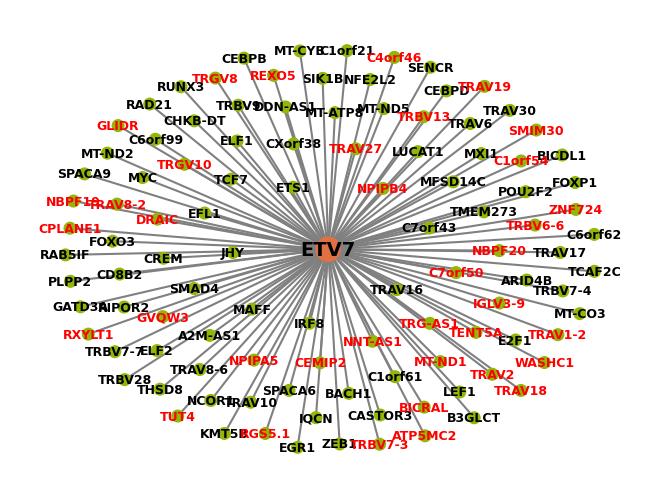

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import rcParams

# -------------------------- Extract Subnetwork --------------------------
for tp in range(1,5):
    df = pd.read_csv("./cytoscape/tumor_prediction" + str(tp) + "_3000.csv")
    new_df = df[df['TF'] == 'ETV7']
    print(f"ETV7 subnetwork for time point {tp}:")
    print(new_df)
    new_df.to_csv('./cytoscape/ETV7_subnetwork' + str(tp) + '.csv', index=False)

# -------------------------- Visualize Subnetwork --------------------------
df3 = pd.read_csv('./cytoscape/tumor_prediction3_3000.csv')
df4 = pd.read_csv('./cytoscape/tumor_prediction4_3000.csv')
print("Data for time point 4:")
print(df4)

# Filter ETV7 target genes
etv7_df3 = list(df3[df3['TF'] == 'ETV7']['Target'].values)
etv7_df4 = list(df4[df4['TF'] == 'ETV7']['Target'].values)

# Get unique genes for each time point
unique_genes3 = list(set(etv7_df3) - set(etv7_df4))
unique_genes4 = list(set(etv7_df4) - set(etv7_df3))

print(f"Unique target genes of ETV7 at time point 3: {unique_genes3}")
print(f"Unique target genes of ETV7 at time point 4: {unique_genes4}")

# Read target network data (time point 4)
df = pd.read_csv('./cytoscape/tumor_prediction4_3000.csv')
etv7_df = df[df['TF'] == 'ETV7']

# Create network graph
G = nx.Graph()
G.add_node('ETV7', size=300, color='#e17145')

# Add target nodes and edges
for idx, row in etv7_df.iterrows():
    target = row['Target']
    color = '#92b708' if row['e_type'] == 1 else '#92b708'
    G.add_node(target, size=70, color=color)
    G.add_edge('ETV7', target)

# Set graph layout
pos = nx.spring_layout(G, seed=42, k=0.6)

# Extract node properties
node_sizes = [data['size'] for _, data in G.nodes(data=True)]
node_colors = [data['color'] for _, data in G.nodes(data=True)]

# Draw network
nx.draw(
    G, pos, with_labels=False, node_size=node_sizes, node_color=node_colors,
    font_size=0, font_weight='bold', edge_color='gray', width=1.5,
    connectionstyle='arc3,rad=0.5'
)

# Draw ETV7 label
etv7_label = {'ETV7': 'ETV7'}
nx.draw_networkx_labels(
    G, pos,
    etv7_label,
    font_size=14,
    font_weight='bold'
)

# Define target genes to highlight in red
target_genes_to_color = ['TRAV18', 'TRBV13', 'SMIM30', 'RXYLT1', 'REXO5', 'TRAV1-2', 'IGLV3-9', 'GVQW3', 
                         'TRAV19', 'NNT-AS1', 'TUT4', 'NPIPA5', 'TRAV27', 'ATP5MC2', 'TRAV8-2', 'CEMIP2', 
                         'CPLANE1', 'C7orf50', 'TRG-AS1', 'TRAV2', 'WASHC1', 'NBPF19', 'BICRAL', 'RGS5.1', 
                         'C4orf46', 'DRAIC', 'TRBV6-6', 'MT-ND1', 'GLIDR', 'NBPF20', 'TRGV8', 'C1orf54', 
                         'TRGV10', 'TRBV7-3', 'NPIPB4', 'TENT5A', 'ZNF724']

# Draw target labels (red for specific genes)
target_labels = {}
target_label_colors = {}
for node in G.nodes():
    if node != 'ETV7':
        target_labels[node] = node
        target_label_colors[node] = 'red' if node in target_genes_to_color else 'black'

# Draw labels by color group
for color in set(target_label_colors.values()):
    color_nodes = [node for node, col in target_label_colors.items() if col == color]
    color_labels = {node: target_labels[node] for node in color_nodes}
    nx.draw_networkx_labels(
        G, pos,
        color_labels,
        font_size=9,
        font_weight='bold',
        font_color=color
    )

plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np

GO_t6 = ['Gastric cancer', 'Pathways in cancer',
         'Transcriptional misregulation in cancer', 'Cell cycle','Wnt signaling pathway','Th17 cell differentiation']
GO_t5 = ['Hepatocellular carcinoma', 'Thyroid cancer',
         'Colorectal cancer', 'Gastric cancer']

val_t6 = [0.0068235969129875,0.0068235969129875,0.0131047110147261,0.015671980922096,0.0255815559125385,0.0455647813627722]
val_t5 = [0.0150044161293665,0.0255855935927139,0.0255855935927139,0.0255855935927139]

values = -np.log10(np.array(val_t6 + val_t5))

fig, ax = plt.subplots(figsize=(9, 7))
bar_width = 0.8
group_spacing = 0.3

t6_start = 0
t6_end = t6_start + len(GO_t6)
t5_start = t6_end + group_spacing
t5_end = t5_start + len(GO_t5)

for i in range(len(GO_t6)):
    val = values[i]
    cat = GO_t6[i]
    ax.barh(t6_start + i, val, height=bar_width, color='#f08400')
    ax.text(0.05, t6_start + i, cat, ha='left', va='center', fontsize=18)

for i in range(len(GO_t5)):
    val = values[len(GO_t6) + i]
    cat = GO_t5[i]
    ax.barh(t5_start + i, val, height=bar_width, color='#82cdd0')
    ax.text(0.05, t5_start + i, cat, ha='left', va='center', fontsize=18)

plt.yticks([])

ax.text(-0.1, t6_start + (t6_end - t6_start) / 2, 'C2', va='center', ha='right',
        color='black', fontsize=22, rotation=90)
ax.text(-0.1, t5_start + (t5_end - t5_start) / 2, 'C8', va='center', ha='right',
        color='black', fontsize=22, rotation=90)

title = ax.set_title('KEGG pathway', fontsize=22)
ax.set_xlabel('-log10(adjusted p - value)', fontsize=18)
title.set_position([0.3, 1.0])

plt.xticks(fontsize=15)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

## 9. In silico perturbation analysis

In [5]:
%run ./in_silico/CD8_in_silico_v3.py

Loading and merging expression data...
Merged expression matrix shape: (1896, 4416) (cells×genes)
Cell counts per state:
C0 (transitional effector)    871
C2 (plastic exhaustion)       696
C3 (naive)                    313
C8 (terminal exhaustion)       16
Name: cluster, dtype: int64

Performing Scanpy preprocessing...
Calculating PCA...
Calculating neighbor graph and UMAP...

Generating UMAP plot of cell clusters...

Calculating Pseudotime for CD8 T cell exhaustion trajectory...
Calculating Diffusion Pseudotime...

Generating UMAP plot for ETV7 expression...
ETV7 expression UMAP plot generated successfully

Initializing Oracle object...
4416 genes were found in the adata. Note that Celloracle is intended to use around 1000-3000 genes, so the behavior with this number of genes may differ from what is expected.
Performing PCA and KNN imputation...

Loading and formatting GRN networks...
C3 (naive): 308495/308495 valid edges
C0 (transitional effector): 308495/308495 valid edges
C2 (plast

  0%|          | 0/4 [00:00<?, ?it/s]


Calculating differentiation vector field for CD8 T cell exhaustion trajectory...
Transferring pseudotime to grid...
Calculating exhaustion trajectory gradient...

Simulating TF knockout: ETV7 ...

Calculating transition probability matrix after perturbation...
Calculating embedding shift after perturbation...
Calculating grid mass after perturbation...
Calculating mass filter after perturbation...
Calculating grid arrows after perturbation...

Generating single-cell vector field comparison plot...
Single-cell vector comparison plot saved

Generating grid vector field comparison plot...
Grid vector field comparison plot saved

Generating cluster + vector field overlay plot...
Overlay plot saved

Comparing exhaustion trajectory vectors vs TF perturbation vectors...


2026-03-14 20:18:10,391 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-14 20:18:10,402 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Perturbation Score plots saved

Analyzing perturbation magnitude...
Magnitude analysis failed: 'delta_embedding'

Calculating statistical data...
Statistical analysis failed: 'delta_embedding'

Saving analysis objects...

All analysis completed! Output directory: ./in_silico/celloracle_output
Exhaustion trajectory vector field plots generated
ETV7 perturbation vector field plots generated
Perturbation Score calculated to evaluate ETV7 impact on exhaustion process
